# 04 — Transformers (M5, M6) and the external reference (M7)

Methodology §3.9.2, §3.10.5–3.10.8, §3.11.3, §3.12.

Two fine-tuned transformers and one off-the-shelf industry detector, run on the same splits,
the same test conditions and the same evaluation code as the baselines in notebook 03.

**Code:** `src/train_transformer.py`, `src/evaluate.py`
**Outputs:** weights in `models/` (git-ignored — re-created by running this notebook),
figures in `results/figures/`, tables in `results/tables/`.

In [1]:
import os, sys, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":        # run from the project root
    os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.dpi"] = 80           # on-screen size only; saved PNGs are 300 dpi
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("working directory:", Path.cwd().name)

working directory: sentinelprompt


In [2]:
import evaluate as ev
import train_transformer as tt
import torch
print("device:", tt.device(), "| torch", torch.__version__)
tr, va = tt.load_data()
conditions = ev.load_conditions()
print(f"train {len(tr)} | validation {len(va)} | conditions: {', '.join(conditions)}")

device: mps | torch 2.14.1
train 462 | validation 100 | conditions: E1_clean, E2_paraphrase, E3_obfuscated, E4_codemix, E5_crossdataset, FP_promptbench, E5x_pooled


### Test conditions

| ID | Test set | Rows | What it asks |
|---|---|---|---|
| **E1** | Test-Clean | 100 | How good is the model on unseen prompts like the training data? |
| **E2** | Test-Paraphrase | E1 rows reworded | Does the same attack, said differently, still get caught? |
| **E3** | Test-Obfuscated | 1,900 | Does it survive leetspeak, spacing, homoglyphs, zero-width, casing, typos, base64? |
| **E4** | Bangla–English (D4) | 900 | Does an English-trained model work on Bangla and code-mixed Bangla? |
| **E5** | Lakera | 1,000 | Does it catch attacks from a source it never saw? (all injections) |
| **FP** | PromptBench | 4,150 | Does it wrongly flag harmless task prompts? (all safe) |
| **E5x** | Lakera + PromptBench | 5,150 | E5 and FP pooled, so ROC-AUC and PR-AUC are defined |

E5 and FP each hold a single class. On those, macro-F1, ROC-AUC and PR-AUC are
undefined and shown as `NaN` on purpose; accuracy there equals recall (E5) or
specificity (FP). E5x pools them so the threshold-free metrics can be computed.

### The >97% accuracy guard

If any model scores above **97% accuracy** on a test condition, the evaluation code
prints a warning and runs a leakage check on that test set against the training set:

* **shared groups** — does any test row belong to a near-duplicate group seen in training?
* **exact text overlap** — is the identical prompt in training?
* **near duplicates** — is a prompt with ≥ 80% character-shingle overlap in training?

Then it says which explanation fits: leakage, a single-class test set (where accuracy
is just recall or specificity), or neither.

### Fine-tuning hyperparameters (§3.11.3), shared by M5 and M6

| Hyperparameter | Value | Why |
|---|---|---|
| learning rate | 2e-5 | larger values erase pre-trained knowledge (*catastrophic forgetting*) |
| optimiser | AdamW, weight decay 0.01 | standard for transformer fine-tuning |
| batch size | 16 | |
| epochs | up to 5, early stopping on validation macro-F1, patience 2 | small data overfits fast |
| LR schedule | linear warm-up over the first 10% of steps, then linear decay | avoids unstable early steps |
| max length | 128 tokens | covers > 99% of prompts (EDA, step 3) |
| gradient clipping | 1.0 | prevents exploding gradients |
| dropout | 0.1 | model default |
| loss | class-weighted cross-entropy | handles the 60/40 class imbalance |
| seeds | 42, 1337, 2024 | results reported as mean ± std over three runs |
| threshold | tuned on validation, per seed | |

**Two deviations from the plan, both hardware-driven:** mixed precision (fp16) is a CUDA
feature, so we train in fp32 on Apple MPS; and the learning-rate search {1e-5 … 5e-5} is not
run, so 2e-5 (the stated default) is used. Figures and per-row predictions come from seed 42.

In [3]:
summary = {}

## M5 — DistilBERT (fine-tuned)

**What it is.** A smaller, faster version of BERT made by *knowledge distillation*: a small
"student" network is trained to imitate a large "teacher" (BERT). It keeps ~97% of BERT's
performance with 6 layers instead of 12 (~66 M parameters) and runs ~60% faster.

**How it works.** The text is split into subword tokens (WordPiece). Every token attends to
every other token through self-attention, so the meaning of a word depends on its context. The
final vector of the special `[CLS]` token goes through dropout and a new linear layer (768 → 2)
that outputs the two class probabilities. **Fine-tuning** updates the whole network on our data;
because the model already knows English from pre-training, a few hundred examples are enough.

**Why we chose it.** Good accuracy for its size, and it answers the speed-vs-accuracy question
(RQ5). Checkpoint: `distilbert-base-uncased` (it lowercases internally, so we do not).

In [4]:
summary["distilbert"] = tt.run_finetuned("distilbert", tr, va, conditions)
display(summary["distilbert"]["per_seed"])
print("mean ± std over seeds:")
display(summary["distilbert"]["mean_std"])

[distilbert seed 42] epoch 1  train loss 0.6459  val macro-F1 0.8271


[distilbert seed 42] epoch 2  train loss 0.3774  val macro-F1 0.9261


[distilbert seed 42] epoch 3  train loss 0.1500  val macro-F1 0.9892


[distilbert seed 42] epoch 4  train loss 0.0710  val macro-F1 0.9785


[distilbert seed 42] epoch 5  train loss 0.0442  val macro-F1 0.9892
[distilbert seed 42] early stop (no val gain for 2 epochs)


...

[distilbert seed 2024] epoch 4  train loss 0.0742  val macro-F1 1.0000


[distilbert seed 2024] epoch 5  train loss 0.0565  val macro-F1 1.0000


,seed,condition,threshold,accuracy,precision,recall,specificity,f1_injection,macro_f1,mcc,roc_auc,pr_auc
0,42,E1_clean,0.6070,0.9400,0.9667,0.8529,0.9848,0.9062,0.9311,0.8660,0.9915,0.9851
1,42,E2_paraphrase,0.6070,0.9250,1.0000,0.8537,1.0000,0.9211,0.9248,0.8601,0.9731,0.9786
2,42,E3_obfuscated,0.6070,0.7889,0.6283,0.9288,0.7169,0.7495,0.7836,0.6118,0.9206,0.8522
3,42,E4_codemix,0.6070,0.6644,0.5984,1.0000,0.3289,0.7488,0.6219,0.4436,0.9358,0.9321
4,42,E5_crossdataset,0.6070,0.9170,1.0000,0.9170,NaN,0.9567,NaN,NaN,NaN,NaN
5,42,FP_promptbench,0.6070,0.0029,0.0000,NaN,0.0029,NaN,NaN,NaN,NaN,NaN
6,42,E5x_pooled,0.6070,0.1804,0.1814,0.9170,0.0029,0.3029,0.1543,-0.2355,0.4279,0.2005
7,1337,E1_clean,0.5670,0.9500,0.9677,0.8824,0.9848,0.9231,0.9430,0.8882,0.9728,0.9676
8,1337,E2_paraphrase,0.5670,0.9250,1.0000,0.8537,1.0000,0.9211,0.9248,0.8601,0.9475,0.9691
9,1337,E3_obfuscated,0.5670,0.7684,0.6028,0.9350,0.6826,0.7330,0.7643,0.5860,0.9064,0.8480


mean ± std over seeds:


,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std
condition,,,,,,,,
E1_clean,0.9500,0.0100,0.9430,0.0119,0.8824,0.0294,0.9874,0.0130
E2_paraphrase,0.9292,0.0072,0.9290,0.0073,0.8780,0.0422,0.9696,0.0206
E3_obfuscated,0.7830,0.0127,0.7784,0.0124,0.9412,0.0164,0.9226,0.0174
E4_codemix,0.6433,0.0185,0.5910,0.0271,1.0000,0.0000,0.9200,0.0139
E5_crossdataset,0.9273,0.0100,NaN,NaN,0.9273,0.0100,NaN,NaN
FP_promptbench,0.0020,0.0008,NaN,NaN,NaN,NaN,NaN,NaN
E5x_pooled,0.1817,0.0014,0.1548,0.0007,0.9273,0.0100,0.3956,0.0754


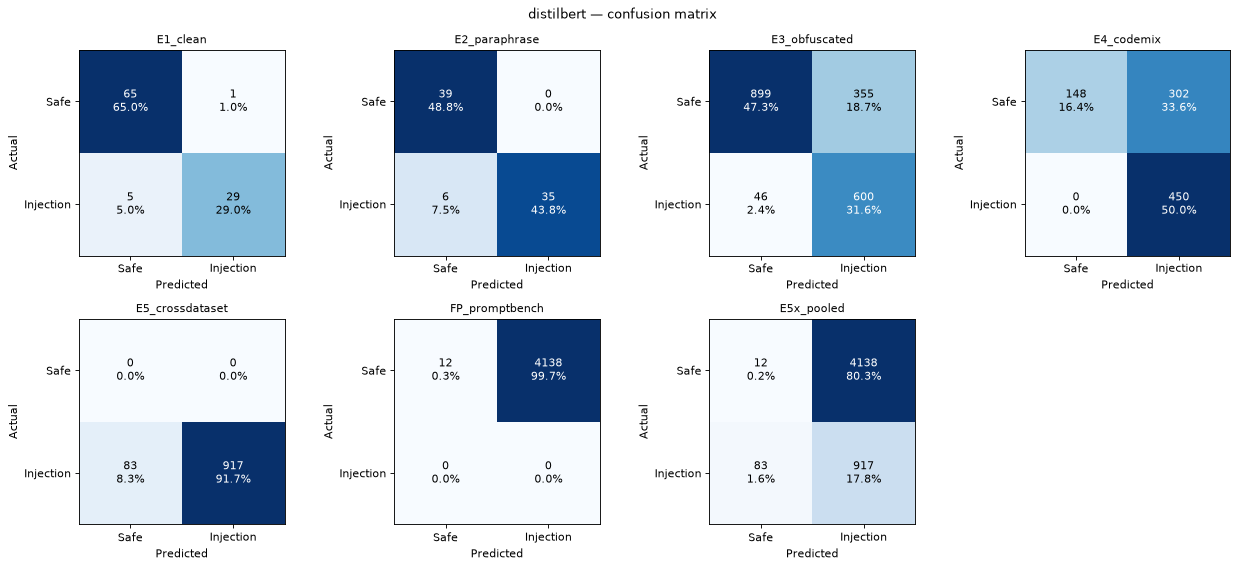

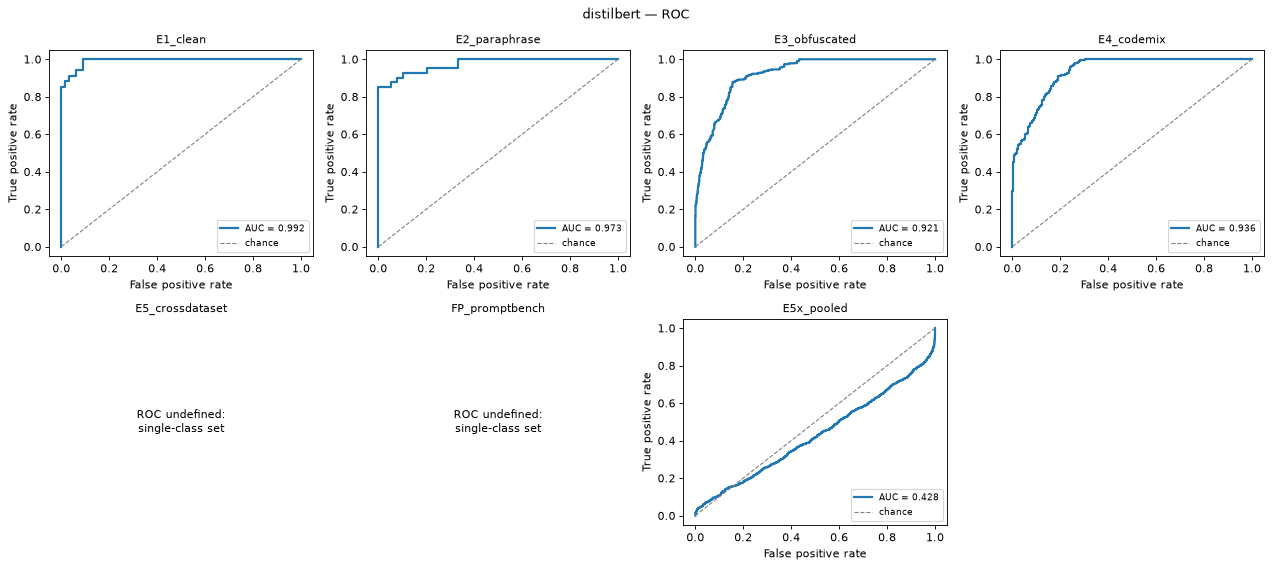

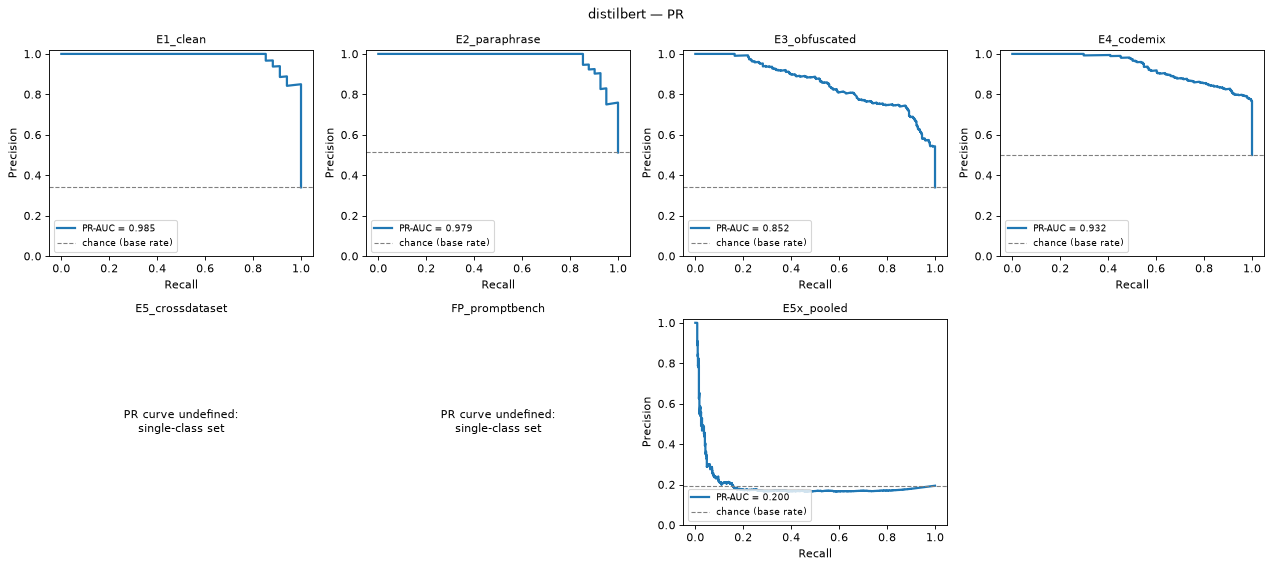

In [5]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(summary["distilbert"]["run42"], kind); plt.show()

## M6 — RoBERTa-base (fine-tuned)

**What it is.** *Robustly Optimised BERT*: the same architecture as BERT-base (12 layers,
~125 M parameters) but pre-trained longer, on more data, with larger batches and dynamic masking,
and without BERT's next-sentence objective.

**How it works.** Same fine-tuning recipe as DistilBERT: subword tokens (byte-level BPE) →
12 layers of self-attention → first-token vector → dropout → linear 768 → 2.

**Why we chose it.** Our strongest fine-tuned competitor. Comparing it with DistilBERT answers
"is a bigger model more robust?" Checkpoint: `roberta-base` (case-sensitive).

In [6]:
summary["roberta"] = tt.run_finetuned("roberta", tr, va, conditions)
display(summary["roberta"]["per_seed"])
print("mean ± std over seeds:")
display(summary["roberta"]["mean_std"])

[roberta seed 42] epoch 1  train loss 0.6548  val macro-F1 0.7917


[roberta seed 42] epoch 2  train loss 0.2440  val macro-F1 0.9783


[roberta seed 42] epoch 3  train loss 0.0797  val macro-F1 1.0000


[roberta seed 42] epoch 4  train loss 0.0106  val macro-F1 0.9892


[roberta seed 42] epoch 5  train loss 0.0020  val macro-F1 0.9891
[roberta seed 42] early stop (no val gain for 2 epochs)


...

[roberta seed 2024] epoch 5  train loss 0.0130  val macro-F1 1.0000



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Unusually high accuracy is a classic symptom of train/test leakage.
Leakage check:
   shared_groups              0
   exact_text_overlap         0
   near_duplicates_in_train   0
   test_rows                  100
   test_is_single_class       False
-> No leakage found. The high score is not explained by overlap.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



,seed,condition,threshold,accuracy,precision,recall,specificity,f1_injection,macro_f1,mcc,roc_auc,pr_auc
0,42,E1_clean,0.5442,0.9700,0.9697,0.9412,0.9848,0.9552,0.9663,0.9329,0.9947,0.9887
1,42,E2_paraphrase,0.5442,0.9625,1.0000,0.9268,1.0000,0.9620,0.9625,0.9277,0.9825,0.9875
2,42,E3_obfuscated,0.5442,0.6805,0.5157,0.9892,0.5215,0.6780,0.6805,0.5079,0.9092,0.8210
3,42,E4_codemix,0.5442,0.6500,0.5882,1.0000,0.3000,0.7407,0.6011,0.4201,0.8279,0.8024
4,42,E5_crossdataset,0.5442,0.9000,1.0000,0.9000,NaN,0.9474,NaN,NaN,NaN,NaN
5,42,FP_promptbench,0.5442,0.0065,0.0000,NaN,0.0065,NaN,NaN,NaN,NaN,NaN
6,42,E5x_pooled,0.5442,0.1800,0.1792,0.9000,0.0065,0.2989,0.1557,-0.2385,0.4877,0.2518
7,1337,E1_clean,0.2898,0.9900,0.9714,1.0000,0.9848,0.9855,0.9889,0.9781,0.9973,0.9946
8,1337,E2_paraphrase,0.2898,0.9625,1.0000,0.9268,1.0000,0.9620,0.9625,0.9277,0.9875,0.9896
9,1337,E3_obfuscated,0.2898,0.6268,0.4766,0.9954,0.4370,0.6446,0.6259,0.4514,0.9171,0.8336


mean ± std over seeds:


,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std
condition,,,,,,,,
E1_clean,0.9800,0.0100,0.9777,0.0113,0.9706,0.0294,0.9952,0.0019
E2_paraphrase,0.9583,0.0072,0.9583,0.0072,0.9187,0.0141,0.9837,0.0033
E3_obfuscated,0.6935,0.0740,0.6924,0.0732,0.9907,0.0041,0.9242,0.0195
E4_codemix,0.6437,0.0057,0.5919,0.0084,1.0000,0.0000,0.8324,0.0528
E5_crossdataset,0.9133,0.0119,NaN,NaN,0.9133,0.0119,NaN,NaN
FP_promptbench,0.0044,0.0018,NaN,NaN,NaN,NaN,NaN,NaN
E5x_pooled,0.1809,0.0011,0.1554,0.0007,0.9133,0.0119,0.3781,0.1223


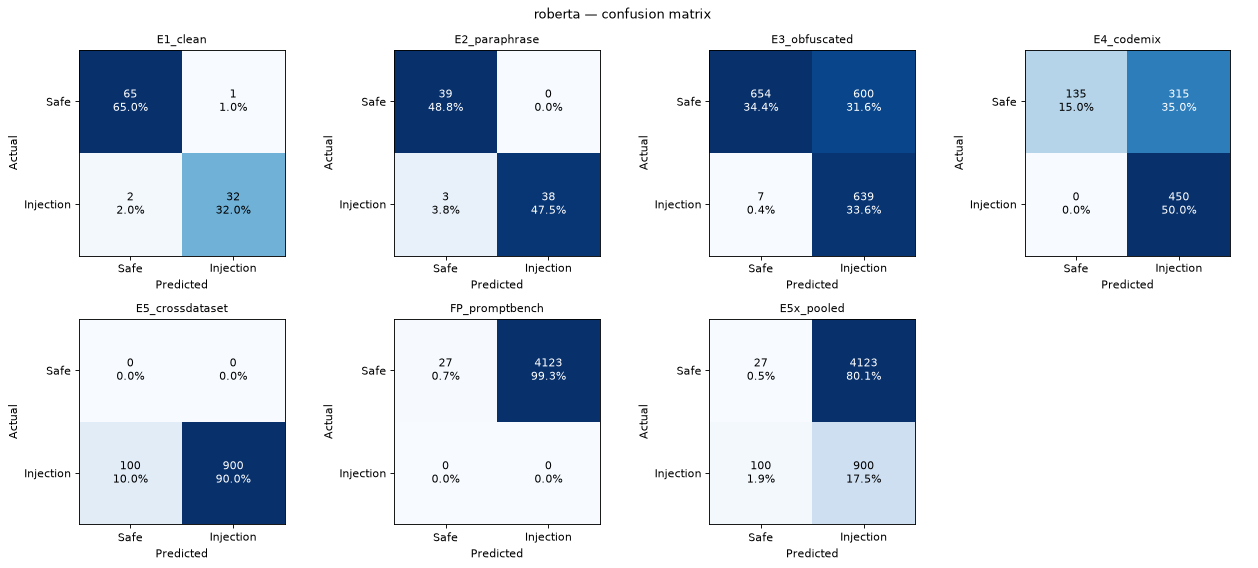

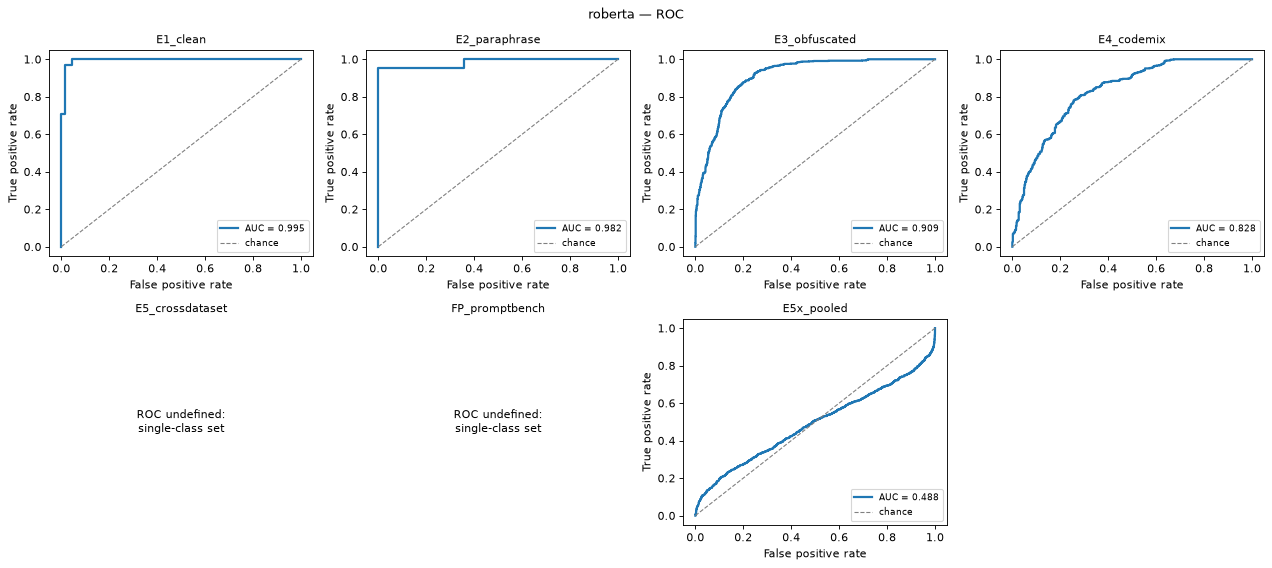

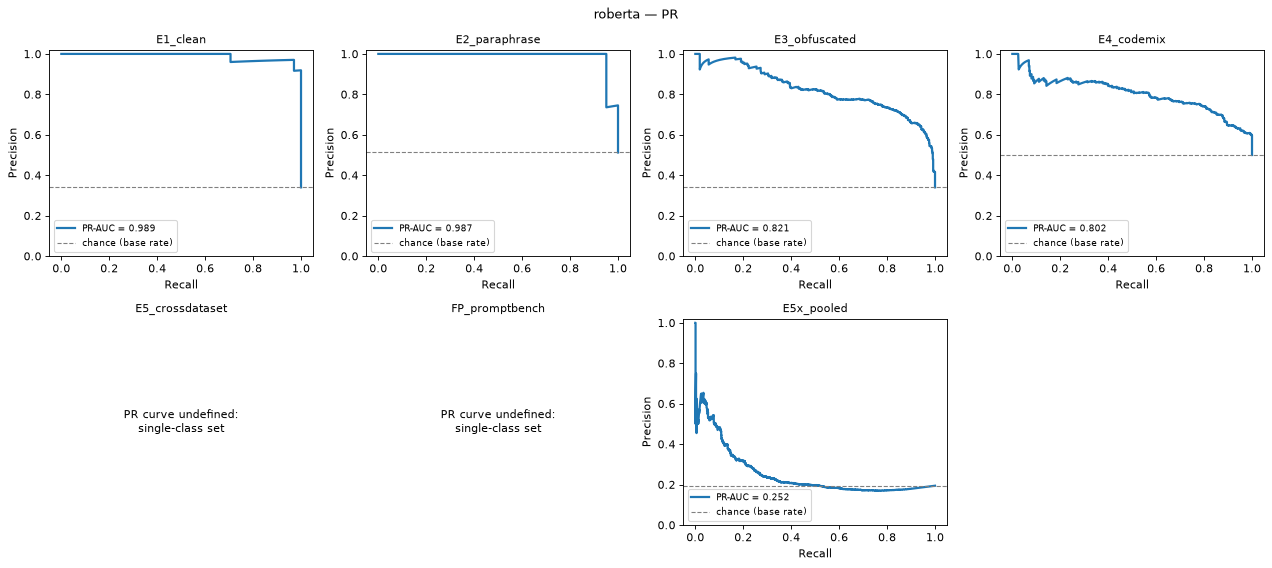

In [7]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(summary["roberta"]["run42"], kind); plt.show()

## M7 — ProtectAI DeBERTa-v3 (zero-shot, external reference)

**What it is.** `protectai/deberta-v3-base-prompt-injection-v2`, an industry prompt-injection
detector built on DeBERTa-v3, which separates *content* and *position* in its attention.

**How it works here.** **No training on our data.** We only run it on our test sets. We keep its
default 0.5 threshold, because tuning a threshold on our validation set would already be adapting
it to our data.

**Why it matters.** It is independent of our small training set. If it also breaks on our new
adversarial and Bangla–English sets, the weakness is not an artefact of our data size — it is a
real gap in current detectors. That makes it the strongest validity check in the study.

In [8]:
summary["protectai_deberta"] = tt.run_external(conditions, tr)
display(ev.tidy(summary["protectai_deberta"]["run42"]["metrics"])[["condition", "n", "threshold",
    "accuracy", "precision", "recall", "specificity", "macro_f1", "mcc", "roc_auc", "pr_auc", "note"]])


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Unusually high accuracy is a classic symptom of train/test leakage.
Leakage check:
   shared_groups              0
   exact_text_overlap         0
   near_duplicates_in_train   0
   test_rows                  1000
   test_is_single_class       True
-> No leakage. The set holds a single class, so accuracy equals recall (or specificity) and says nothing about the other class.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!




!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Unusually high accuracy is a classic symptom of train/test leakage.
Leakage check:
   shared_groups              0
   exact_text_overlap         0
   near_duplicates_in_train   0
   test_rows                  4150
   test_is_single_class       True
-> No leakage. The set holds a single class, so accuracy equals recall (or specificity) and says nothing about the other class.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!




!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Unusually high accuracy is a classic symptom of train/test leakage.
Leakage check:
   shared_groups              0
   exact_text_overlap         0
   near_duplicates_in_train   0
   test_rows                  5150
   test_is_single_class       False
-> No leakage found. The high score is not explained by overlap.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



,condition,n,threshold,accuracy,precision,recall,specificity,macro_f1,mcc,roc_auc,pr_auc,note
0,E1_clean,100,0.5000,0.7900,1.0000,0.3824,1.0000,0.7080,0.5386,0.8837,0.8592,NaN
1,E2_paraphrase,80,0.5000,0.6250,1.0000,0.2683,1.0000,0.5726,0.3894,0.8587,0.8867,NaN
2,E3_obfuscated,1900,0.5000,0.7063,0.5587,0.6486,0.7360,0.6841,0.3728,0.7602,0.5717,NaN
3,E4_codemix,900,0.5000,0.7844,0.7058,0.9756,0.5933,0.7763,0.6156,0.9392,0.9412,NaN
4,E5_crossdataset,1000,0.5000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,all-injection set: accuracy = recall
5,FP_promptbench,4150,0.5000,0.9716,0.0000,NaN,0.9716,NaN,NaN,NaN,NaN,all-safe set: accuracy = specificity
6,E5x_pooled,5150,0.5000,0.9771,0.8945,1.0000,0.9716,0.9649,0.9322,0.9998,0.9991,NaN


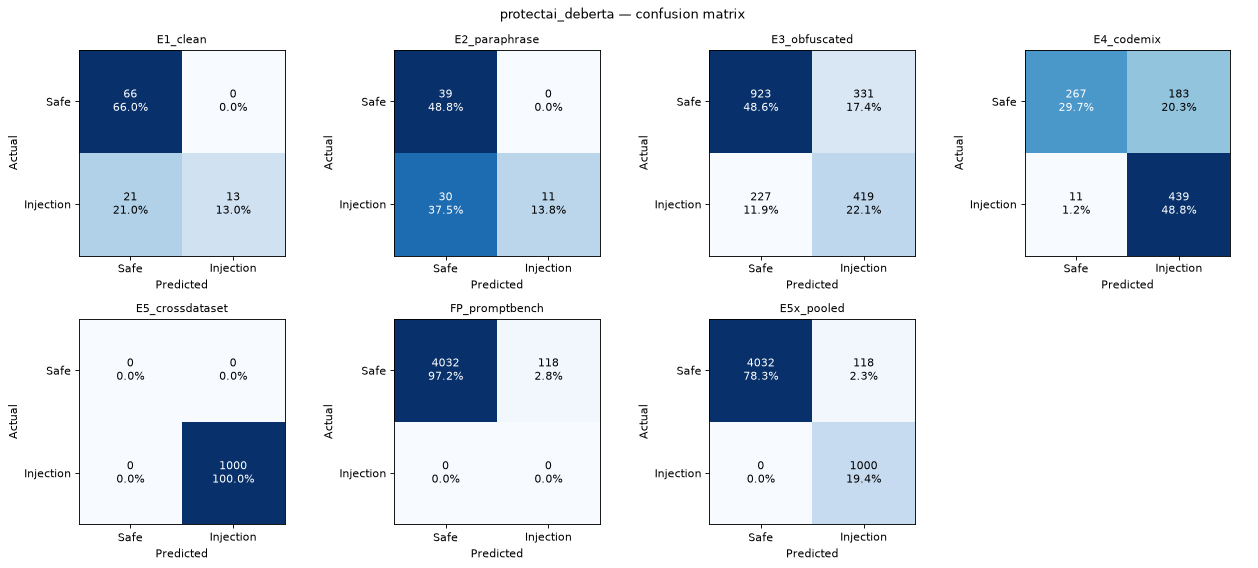

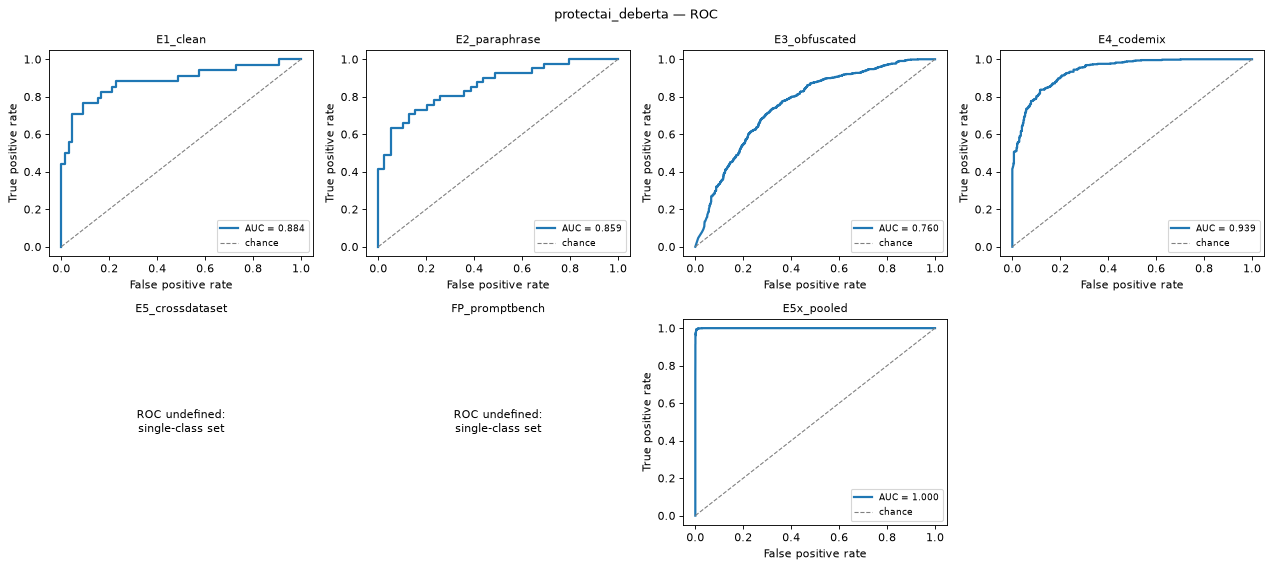

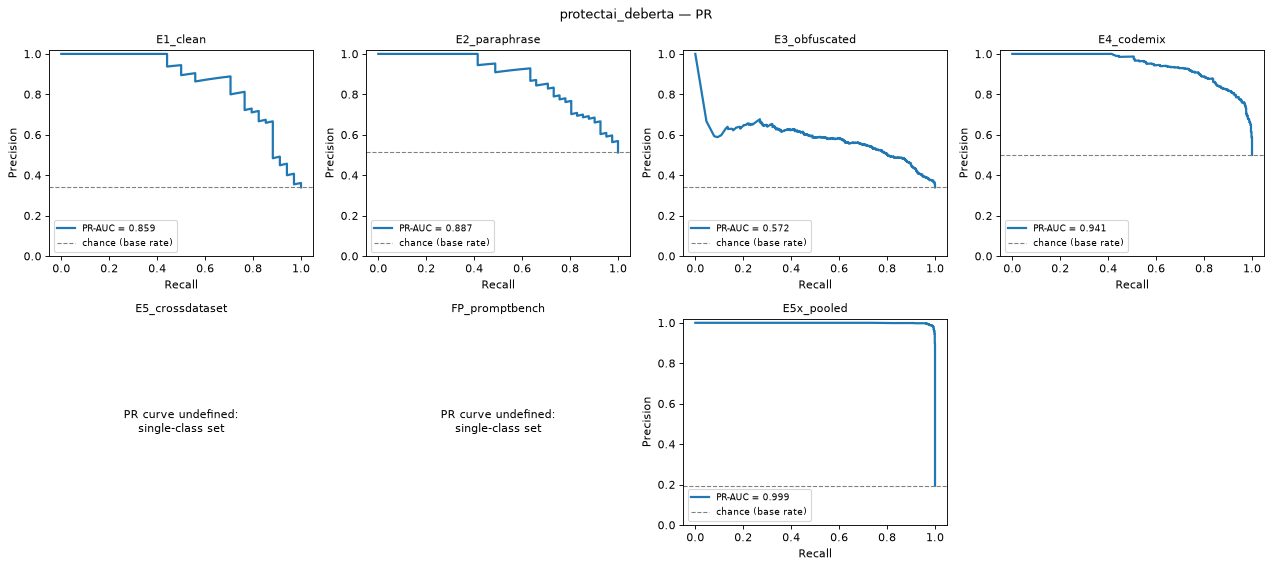

In [9]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(summary["protectai_deberta"]["run42"], kind); plt.show()

## Comparison and efficiency (E7)

model,distilbert,protectai_deberta,roberta
condition,,,
E1_clean,0.9430,0.7080,0.9777
E2_paraphrase,0.9290,0.5726,0.9583
E3_obfuscated,0.7784,0.6841,0.6924
E4_codemix,0.5910,0.7763,0.5919
E5_crossdataset,NaN,NaN,NaN
FP_promptbench,NaN,NaN,NaN
E5x_pooled,0.1548,0.9649,0.1554


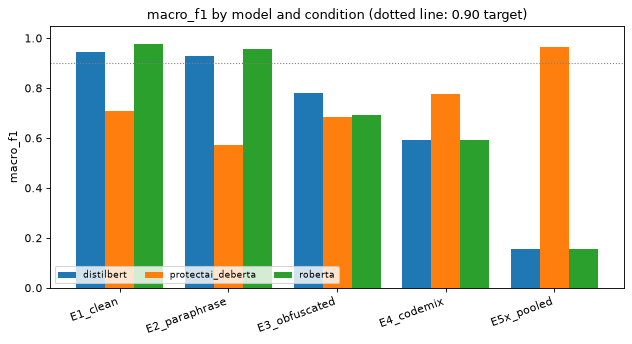

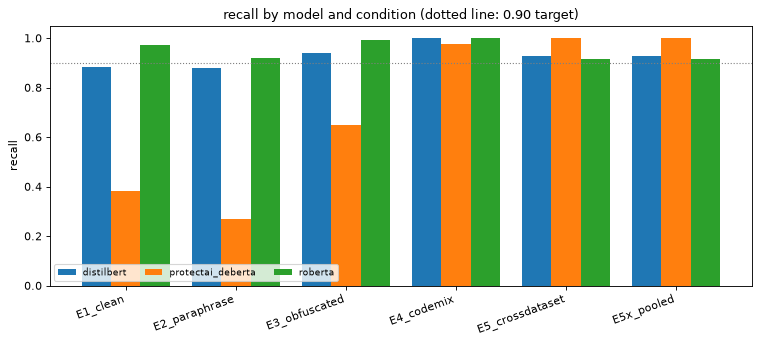

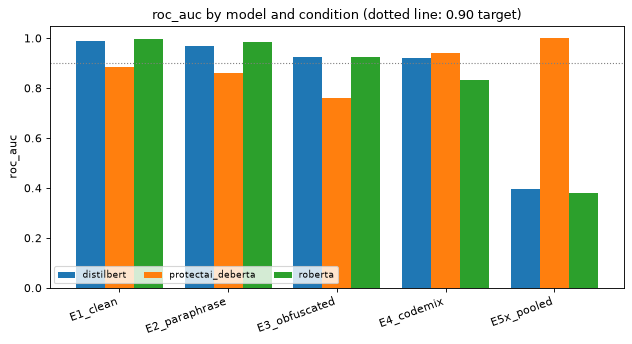

,model,threshold,val_macro_f1,epochs_run,train_seconds,params_million,size_mb,latency_ms_median,latency_ms_p95
0,distilbert,0.5446,0.9928,5.0000,54.2667,67.0000,268.5000,6.2467,10.0000
1,roberta,0.3429,0.9964,5.0000,152.6333,124.6000,502.2000,12.5267,17.7300
2,protectai_deberta,0.5000,NaN,NaN,NaN,184.4000,NaN,17.5000,30.1200


In [10]:
metrics = tt.save_all(summary)
display(metrics.pivot_table(index="condition", columns="model", values="macro_f1")
        .reindex([c for c in ev.CONDITIONS if c in metrics.condition.unique()]))
for m in ["macro_f1", "recall", "roc_auc"]:
    ev.comparison_chart(metrics, m, name=f"transformers_comparison_{m}"); plt.show()
display(pd.read_csv("results/tables/transformers_efficiency.csv"))

## Key findings (computed)

In [11]:
def f(m, c, col="macro_f1"):
    v = metrics[(metrics.model == m) & (metrics.condition == c)][col]
    return float(v.iloc[0]) if len(v) else float("nan")
for m in summary:
    print(f"{m:18s} E1 {f(m,'E1_clean'):.3f} | E2 {f(m,'E2_paraphrase'):.3f} | E3 {f(m,'E3_obfuscated'):.3f}"
          f" | E4 {f(m,'E4_codemix'):.3f} | E5 recall {f(m,'E5_crossdataset','recall'):.3f}"
          f" | FP false-positive rate {1 - f(m,'FP_promptbench','specificity'):.3f}")

distilbert         E1 0.943 | E2 0.929 | E3 0.778 | E4 0.591 | E5 recall 0.927 | FP false-positive rate 0.998
roberta            E1 0.978 | E2 0.958 | E3 0.692 | E4 0.592 | E5 recall 0.913 | FP false-positive rate 0.996
protectai_deberta  E1 0.708 | E2 0.573 | E3 0.684 | E4 0.776 | E5 recall 1.000 | FP false-positive rate 0.028
